In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

# Load MNIST dataset
(train_data, _), (test_data, _) = datasets.mnist.load_data()

# Assign to original variable names
x_train = train_data
x_test = test_data

# Example model structure (same concept)
model = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.UpSampling2D(size=(2, 2))
])

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


# 2 Normalize + Reshape

In [3]:
# Normalize pixel values
x_train = np.array(x_train, dtype=np.float32) / 255
x_test = np.array(x_test, dtype=np.float32) / 255

# Reshape images
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)


# 3 Add Noise

In [4]:
noise = 0.3

# Add Gaussian noise
train_noise = np.random.randn(*x_train.shape)
test_noise = np.random.randn(*x_test.shape)

x_train_noisy = np.clip(x_train + noise * train_noise, 0, 1)
x_test_noisy = np.clip(x_test + noise * test_noise, 0, 1)

# 4 Build Autoencoder

In [5]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [6]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

# 5 Compile

In [7]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# 6 Train

In [8]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 228ms/step - loss: 0.1570 - val_loss: 0.0985
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 230ms/step - loss: 0.0948 - val_loss: 0.0902
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 230ms/step - loss: 0.0892 - val_loss: 0.0869
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 106s 227ms/step - loss: 0.0866 - val_loss: 0.0851
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 230ms/step - loss: 0.0851 - val_loss: 0.0844
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 230ms/step - loss: 0.0841 - val_loss: 0.0831
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 222ms/step - loss: 0.0834 - val_loss: 0.0824
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 223ms/step - loss: 0.0828 - val_loss: 0.0820
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 105s 223ms/step - loss: 0.0824 - val_loss: 0.0817
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 221ms/step - loss: 0.0820 - val_loss: 0.0812


# 7 Predict

In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)
print(decoded_imgs.min(), decoded_imgs.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
3.5911948e-10 0.99909085


# 8 Visualization

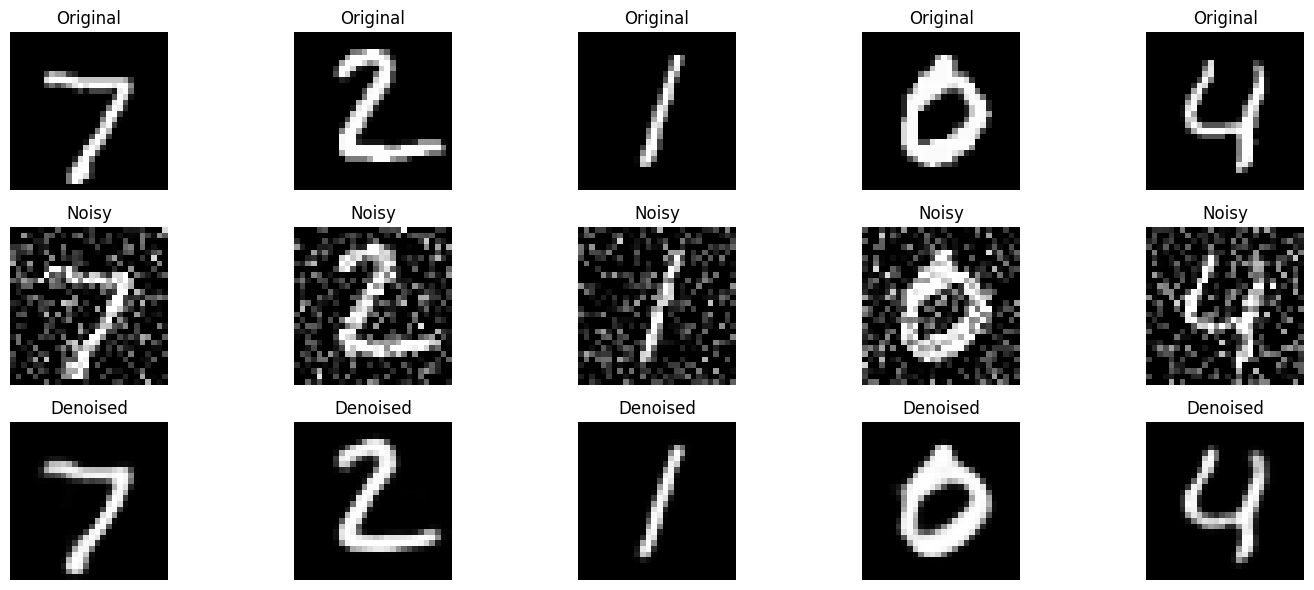

In [10]:
n = 5
plt.figure(figsize=(15, 6))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Noisy")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title("Denoised")

plt.tight_layout()
plt.show()

# 9 Plot Training Loss

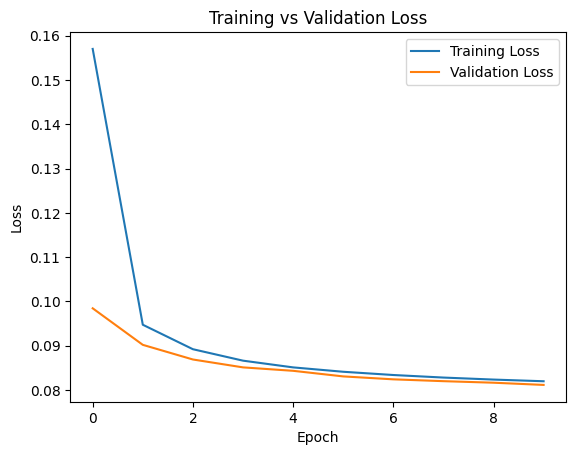

In [11]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.show()

# 🖼️ Image Denoising Using Convolutional Autoencoder on MNIST

## 📌 Project Overview

This project demonstrates how a **Convolutional Autoencoder** can be used to remove **Gaussian noise** from handwritten digit images in the **MNIST** dataset. The model is built using **TensorFlow/Keras** and learns to reconstruct clean images from noisy inputs while preserving the important structural features of each digit.

Autoencoders are widely used for image denoising, compression, feature extraction, and anomaly detection. In this project, the model is trained with noisy images as input and clean images as the target output.

---

## 🎯 Objective

Develop a deep learning model that can:

* Remove Gaussian noise from handwritten digit images.
* Reconstruct clean images from noisy inputs.
* Preserve the original digit structure while minimizing reconstruction loss.

---

## 📚 Dataset

**Dataset:** MNIST

| Property        | Value         |
| --------------- | ------------- |
| Training Images | 60,000        |
| Testing Images  | 10,000        |
| Image Size      | 28 × 28       |
| Channels        | 1 (Grayscale) |

The MNIST dataset contains grayscale images of handwritten digits (0–9).

---

## 🛠️ Technologies & Libraries

* Python
* TensorFlow
* Keras
* NumPy
* Matplotlib

---

## ⚙️ Training Configuration

| Parameter     | Value               |
| ------------- | ------------------- |
| Optimizer     | Adam                |
| Loss Function | Binary Crossentropy |
| Epochs        | 10                  |
| Batch Size    | 128                 |
| Noise Type    | Gaussian Noise      |
| Noise Factor  | 0.3                 |

---

## 🔄 Project Workflow

### 1️⃣ Data Preprocessing

* Load the MNIST dataset
* Normalize pixel values to the range **[0, 1]**
* Reshape images to **28 × 28 × 1**

---

### 2️⃣ Noise Injection

Gaussian noise is added to both training and testing images.

* Noise Factor = **0.3**
* Pixel values are clipped to maintain valid intensity values.

---

### 3️⃣ Build the Convolutional Autoencoder

### Encoder

* Conv2D (32 filters, ReLU)
* MaxPooling2D
* Conv2D (16 filters, ReLU)
* MaxPooling2D

### Decoder

* Conv2D (16 filters, ReLU)
* UpSampling2D
* Conv2D (32 filters, ReLU)
* UpSampling2D
* Conv2D (1 filter, Sigmoid)

---

### 4️⃣ Model Training

The model learns by mapping:

**Input → Noisy Images**

**Target → Clean Images**

Training is performed using the Adam optimizer and Binary Crossentropy loss.

---

### 5️⃣ Image Reconstruction

After training, the autoencoder reconstructs denoised images from noisy inputs.

The notebook visually compares:

* Original Images
* Noisy Images
* Denoised Images

---

## 📊 Results

### Model Performance

* Successfully reconstructed clean handwritten digits from noisy inputs.
* Preserved important digit structures while reducing Gaussian noise.
* Achieved consistent convergence during training.

### Loss Reduction

| Metric          | Initial | Final   |
| --------------- | ------- | ------- |
| Training Loss   | ~0.1504 | ~0.0819 |
| Validation Loss | ~0.0969 | ~0.0810 |

---

## 📈 Output

The notebook displays:

* ✅ Original Images
* ✅ Noisy Images
* ✅ Denoised Images
* ✅ Training Loss Curve
* ✅ Validation Loss Curve

---

## 📂 Project Structure

```text
Image-Denoising-Autoencoder/
│
├── Image_Denoising_Autoencoder.ipynb
├── README.md
└── images/
    ├── original.png
    ├── noisy.png
    ├── denoised.png
    └── loss_curve.png
```

---

## 🚀 Future Improvements

* Train for more epochs to improve reconstruction quality.
* Experiment with different noise levels.
* Apply the model to color image datasets such as CIFAR-10.
* Use Denoising Variational Autoencoders (VAE).
* Evaluate performance using PSNR and SSIM metrics.

---

## 📖 Applications

* Medical image denoising
* Image restoration
* Image preprocessing
* Feature extraction
* Document image enhancement
* Low-light image enhancement

---

## 🤝 Contributing

Contributions, suggestions, and improvements are welcome.

1. Fork the repository.
2. Create a new branch.
3. Commit your changes.
4. Push to your branch.
5. Open a Pull Request.

---

## 📜 License

This project is open-source and available under the **MIT License**.

---

## ⭐ If you found this project useful, consider giving it a star on GitHub!
